Name: Callista Gianna Then

NIM: 2802498293


*info for the rest of this file, I will be mixing indo and english, since some terms are easier to explain in english for myself and some in indonesian, some of these notes are the thought process

ALL VIDEOS WILL BE UPLOADED HERE

https://drive.google.com/drive/folders/1s13iXH1tdl9Hcd2FB1iM0TBEEjmEQsdx?usp=sharing

Dataset D

https://tinyurl.com/DeepLearningNo1

## About The Dataset

Dataset ini berisi harga harian historis untuk beberapa saham sektor teknologi.

berhubungan sama trend, seasonality & waktu --> LSTM

Struktur Data:
- Date - menunjukkan tanggal perdagangan
- Open - harga pembukaan
- High - harga maksimum selama sehari
- Low - harga minimum selama sehari
- Close - harga penutupan disesuaikan untuk pemecahan
-  Adj Close - harga penutupan disesuaikan yang telah disesuaikan untuk dividen dan pemecahan.
- Volume - jumlah saham yang berpindah tangan selama sehari


ADJ close menarik karena walaupun price stocknya sendiri drops that doesnt mean that the value itself drops, as in orang yang sudah sempet megang share saham tersebut does not lose any shares, however the share may double and the price may half-en (?) just to broaden the target market, so more ppl wanna buy since its half the price, but still it doesnt mean that the people who already bought the share, rugi (is at loss)

*we'll look into this later

setiap nama file adalah simbol ticker yang sesuai, sebagai berikut:
-  AAPL Apple Inc.
-  AMZN Amazon.com, Inc
-  AMD Advanced Micro Devices, Inc
- CSCO Cisco Systems, Inc.
- GOOGL Alphabet Inc.
- FB Facebook, Inc
- IBM International Business Machines Corporation
- INTC Intel Corporation

## Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings('ignore')

In [2]:
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 5)

## Load Dataset

In [4]:
dfFB  = pd.read_csv('FB.csv',  parse_dates=['Date'])
dfIBM = pd.read_csv('IBM.csv', parse_dates=['Date'])

### FB dataset

In [5]:
dfFB.shape

(1980, 7)

In [6]:
dfFB.head(15)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-05-18,42.049999,45.000000,38.000000,38.230000,38.230000,573576400
1,2012-05-21,36.529999,36.660000,33.000000,34.029999,34.029999,168192700
2,2012-05-22,32.610001,33.590000,30.940001,31.000000,31.000000,101786600
3,2012-05-23,31.370001,32.500000,31.360001,32.000000,32.000000,73600000
4,2012-05-24,32.950001,33.209999,31.770000,33.029999,33.029999,50237200
5,2012-05-25,32.900002,32.950001,31.110001,31.910000,31.910000,37149800
6,2012-05-29,31.480000,31.690001,28.650000,28.840000,28.840000,78063400
7,2012-05-30,28.700001,29.549999,27.860001,28.190001,28.190001,57267900
8,2012-05-31,28.549999,29.670000,26.830000,29.600000,29.600000,111639200
9,2012-06-01,28.889999,29.150000,27.389999,27.719999,27.719999,41855500


kalo dilihat sekilas gaada string value yang tiba" di column numerical

In [7]:
dfFB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1980 non-null   datetime64[ns]
 1   Open       1980 non-null   float64       
 2   High       1980 non-null   float64       
 3   Low        1980 non-null   float64       
 4   Close      1980 non-null   float64       
 5   Adj Close  1980 non-null   float64       
 6   Volume     1980 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 108.4 KB


the datatye of the variable alredy fits the variable description

In [8]:
dfFB.describe(include = "all")

,Date,Open,High,Low,Close,Adj Close,Volume
count,1980,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000,1.980000e+03
mean,2016-04-25 13:57:05.454545408,112.285808,113.508752,111.011495,112.312207,112.312207,3.301999e+07
min,2012-05-18 00:00:00,18.080000,18.270000,17.549999,17.730000,17.730000,5.913100e+06
25%,2014-05-08 18:00:00,64.647497,65.575001,63.817501,64.762499,64.762499,1.616085e+07
50%,2016-04-26 12:00:00,113.810001,114.654999,112.945000,113.810001,113.810001,2.405750e+07
75%,2018-04-13 18:00:00,167.852505,169.492496,166.022499,168.085003,168.085003,3.986862e+07
max,2020-04-01 00:00:00,222.570007,224.199997,221.279999,223.229996,223.229996,5.735764e+08
std,NaN,58.080987,58.584028,57.575041,58.133793,58.133793,2.959716e+07


there are no invalid values in the data, seeing that the data type in df.info(), above is also consistent between the variable and the expected data type

yang bisa jadi identifier buat duplicated data itu date nya

because its not impossible for a stock to have the same low, OR the same high OR the same adj

even though its rare, just to anticipate the fact that it isnt possible, then we use date

but in cases of a time series data, we dont drop date even though its an identifier column

a time series data plots a relationship between time as the x variable and the stock price as the y variable, and the lstm is supposed to

In [9]:
dfFB.duplicated().sum()

np.int64(0)

In [10]:
#cek missing
dfFB.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [11]:
#cek date mulainya, date plg kecil
dfFB["Date"].min()

Timestamp('2012-05-18 00:00:00')

In [12]:
#cek date end nya, yg paling gede
dfFB["Date"].max()

Timestamp('2020-04-01 00:00:00')

In [13]:
dfFB.head(15)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-05-18,42.049999,45.000000,38.000000,38.230000,38.230000,573576400
1,2012-05-21,36.529999,36.660000,33.000000,34.029999,34.029999,168192700
2,2012-05-22,32.610001,33.590000,30.940001,31.000000,31.000000,101786600
3,2012-05-23,31.370001,32.500000,31.360001,32.000000,32.000000,73600000
4,2012-05-24,32.950001,33.209999,31.770000,33.029999,33.029999,50237200
5,2012-05-25,32.900002,32.950001,31.110001,31.910000,31.910000,37149800
6,2012-05-29,31.480000,31.690001,28.650000,28.840000,28.840000,78063400
7,2012-05-30,28.700001,29.549999,27.860001,28.190001,28.190001,57267900
8,2012-05-31,28.549999,29.670000,26.830000,29.600000,29.600000,111639200
9,2012-06-01,28.889999,29.150000,27.389999,27.719999,27.719999,41855500


newest dimasukin di tail

yang ngga konsisten di sini adalah datenya,

beberapa date ada gap antara mereka walaupun seharusnya dalam satu window size (5, monday to friday)

In [14]:
#but if we check that with the code

fb_weekends = dfFB[dfFB['Date'].dt.dayofweek >= 5]
print(f"Weekends: {len(fb_weekends)}")

Weekends: 0


weekends in the FB dataset is not noted in the dataset

In [15]:
dfFB['Date'].head(10)

,Date
0,2012-05-18
1,2012-05-21
2,2012-05-22
3,2012-05-23
4,2012-05-24
5,2012-05-25
6,2012-05-29
7,2012-05-30
8,2012-05-31
9,2012-06-01


In [16]:
print(dfFB['Close'].head(10))
print(dfFB['Adj Close'].head(10))

0    38.230000
1    34.029999
2    31.000000
3    32.000000
4    33.029999
5    31.910000
6    28.840000
7    28.190001
8    29.600000
9    27.719999
Name: Close, dtype: float64
0    38.230000
1    34.029999
2    31.000000
3    32.000000
4    33.029999
5    31.910000
6    28.840000
7    28.190001
8    29.600000
9    27.719999
Name: Adj Close, dtype: float64


kalo di lihat sekilas dari the first 10 values and the last 10 values of 'Close' and 'Adj Close' in FB dataset, valuesnya sama

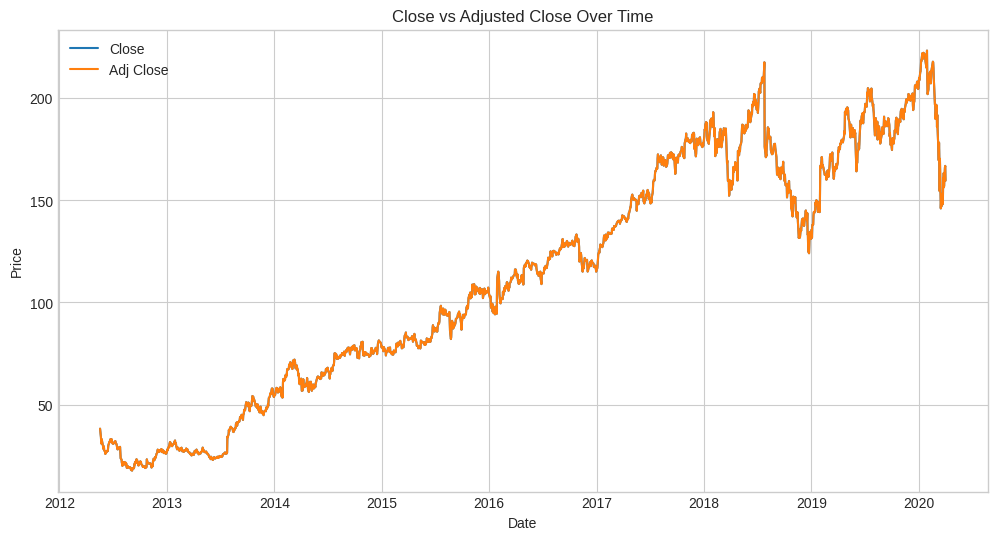

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(dfFB['Date'], dfFB['Close'], label='Close')
plt.plot(dfFB['Date'], dfFB['Adj Close'], label='Adj Close')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Close vs Adjusted Close Over Time')
plt.legend()
plt.grid(True)

plt.show()

they overlap, so, all of the values of Close and Adj Close, is the same consistently for FB dataset, meaning they never performed any stock split

### IBM Dataset

In [18]:
dfIBM.shape

(14663, 7)

In [19]:
dfFB.head(15)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-05-18,42.049999,45.000000,38.000000,38.230000,38.230000,573576400
1,2012-05-21,36.529999,36.660000,33.000000,34.029999,34.029999,168192700
2,2012-05-22,32.610001,33.590000,30.940001,31.000000,31.000000,101786600
3,2012-05-23,31.370001,32.500000,31.360001,32.000000,32.000000,73600000
4,2012-05-24,32.950001,33.209999,31.770000,33.029999,33.029999,50237200
5,2012-05-25,32.900002,32.950001,31.110001,31.910000,31.910000,37149800
6,2012-05-29,31.480000,31.690001,28.650000,28.840000,28.840000,78063400
7,2012-05-30,28.700001,29.549999,27.860001,28.190001,28.190001,57267900
8,2012-05-31,28.549999,29.670000,26.830000,29.600000,29.600000,111639200
9,2012-06-01,28.889999,29.150000,27.389999,27.719999,27.719999,41855500


no strings found in columns so far

In [20]:
dfFB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1980 non-null   datetime64[ns]
 1   Open       1980 non-null   float64       
 2   High       1980 non-null   float64       
 3   Low        1980 non-null   float64       
 4   Close      1980 non-null   float64       
 5   Adj Close  1980 non-null   float64       
 6   Volume     1980 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 108.4 KB


data sama datatypenya

date --> datetime bener

open --> cost --> float bener

high --> cost --> float bener

low --> cost --> float bener

close --> cost --> float bener

Adj close --> cost --> float bener

volume --> brp yang di jual di hari itu --> int bener

from looking at the overall datatype of the variables in IBM dataset, its seen that there are no string characters that are misplaced in a variable that is supposed to be numerical\

and there are no categorical variables implied in the columns

In [21]:
dfFB.describe(include = "all")

,Date,Open,High,Low,Close,Adj Close,Volume
count,1980,1980.000000,1980.000000,1980.000000,1980.000000,1980.000000,1.980000e+03
mean,2016-04-25 13:57:05.454545408,112.285808,113.508752,111.011495,112.312207,112.312207,3.301999e+07
min,2012-05-18 00:00:00,18.080000,18.270000,17.549999,17.730000,17.730000,5.913100e+06
25%,2014-05-08 18:00:00,64.647497,65.575001,63.817501,64.762499,64.762499,1.616085e+07
50%,2016-04-26 12:00:00,113.810001,114.654999,112.945000,113.810001,113.810001,2.405750e+07
75%,2018-04-13 18:00:00,167.852505,169.492496,166.022499,168.085003,168.085003,3.986862e+07
max,2020-04-01 00:00:00,222.570007,224.199997,221.279999,223.229996,223.229996,5.735764e+08
std,NaN,58.080987,58.584028,57.575041,58.133793,58.133793,2.959716e+07


there are no found unreasonable values, when looking at the max or the min values between low, high, close, and open

both minimum values of all close, open, high and low are within a similar range, less than 1 in difference

and the max columns are also within a similar range of 3 dollars



In [22]:
dfIBM.duplicated().sum()

np.int64(0)

In [23]:
#cek missing
dfIBM.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [24]:
#cek date mulainya, date plg kecil
dfIBM["Date"].min()

Timestamp('1962-01-02 00:00:00')

In [25]:
dfIBM["Date"].max()

Timestamp('2020-04-01 00:00:00')

In [26]:
dfIBM['Date'].head(15)

,Date
0,1962-01-02
1,1962-01-03
2,1962-01-04
3,1962-01-05
4,1962-01-08
5,1962-01-09
6,1962-01-10
7,1962-01-11
8,1962-01-12
9,1962-01-15


there are still inconsistencies between the date and the window

as in the window size is 5, representing monday, tuesday, wednesday, thursday and friday

dates should be consistently 5 consecutive days and then a jump of 2 days

in our data, date is shown to be inconsistent

as in

1. 1962-01-02 --> google searched, this is a tuesday
2. 1962-01-03 --> wed
3. 1962-01-04 --> thurs
4. 1962-01-05 --> fri
5. 1962-01-08 --> sat HARUSNYA no change in close, soalnya market dont open at weekends
6. 1962-01-09 --> sun, also a weekend
7. 1962-01-10
8. 1962-01-11
9. 1962-01-12

this is 9 consecutive days, meaning that it includes weekends in the data

In [27]:
dates = pd.to_datetime(['1962-01-05', '1962-01-08', '1962-01-09'])

rows = dfIBM[dfIBM['Date'].isin(dates)]
print(rows)

        Date      Open      High       Low     Close  Adj Close  Volume
3 1962-01-05  7.606667  7.606667  7.453333  7.466667   0.605185  363200
4 1962-01-08  7.460000  7.460000  7.266667  7.326667   0.593837  544000
5 1962-01-09  7.360000  7.506667  7.360000  7.413333   0.600862  491200


there were still saturday and sunday openings in the IBM stock back in the 1960s

some sources mention that no there are no general weekend tradings back then, but some implied that saturday tradings were present and then gradually lessen

In [28]:
#but if we check that with the code

ibm_weekends = dfIBM[dfIBM['Date'].dt.dayofweek >= 5]
print(f"Weekends: {len(ibm_weekends)}")

Weekends: 0


then there are no weekend days noted in the dataset, the date counting above this was wrong

In [29]:
dfIBM.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
14658,2020-03-26,106.910004,113.150002,105.570000,112.889999,112.889999,7153500
14659,2020-03-27,108.580002,111.500000,107.650002,108.029999,108.029999,6423000
14660,2020-03-30,108.089996,113.459999,107.809998,112.930000,112.930000,5564500
14661,2020-03-31,112.000000,113.809998,110.169998,110.930000,110.930000,6343300
14662,2020-04-01,106.360001,109.919998,104.519997,105.139999,105.139999,6111900


newest masuk di tail

In [30]:
print(dfIBM['Close'].head(10))
print(dfIBM['Adj Close'].head(10))

0    7.626667
1    7.693333
2    7.616667
3    7.466667
4    7.326667
5    7.413333
6    7.426667
7    7.506667
8    7.520000
9    7.553333
Name: Close, dtype: float64
0    0.618153
1    0.623556
2    0.617343
3    0.605185
4    0.593837
5    0.600862
6    0.601942
7    0.608427
8    0.609508
9    0.612209
Name: Adj Close, dtype: float64


ada perbedaan dalam adj close sama close di dataset IBM

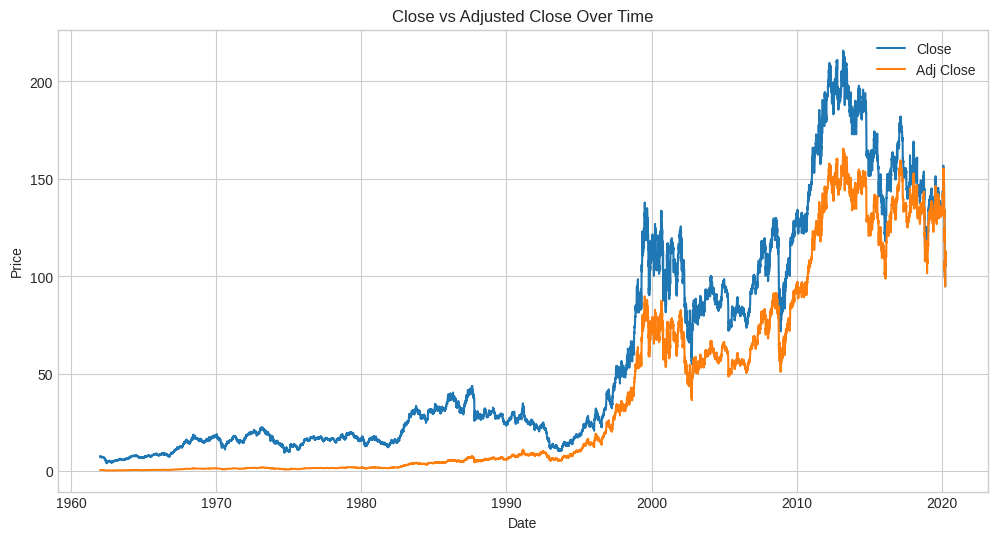

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(dfIBM['Date'], dfIBM['Close'], label='Close')
plt.plot(dfIBM['Date'], dfIBM['Adj Close'], label='Adj Close')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Close vs Adjusted Close Over Time')
plt.legend()
plt.grid(True)

plt.show()

In [32]:
#whats the max diff between close and adj close in IBM for 2019 above, since we're only using the data from the previous one year

dfIBM[dfIBM['Date']>='2019-01-01']['Close'].sub(dfIBM[dfIBM['Date']>='2019-01-01']['Adj Close']).abs().max()

7.5833282470703125

In [33]:
dfIBM['Close'].sub(dfIBM['Adj Close']).abs().max()

51.52720642089844

IBM stock did stock splitting and divident distribution back in the 1960s, this can cause the difference in Close and Adj Close

https://www.ibm.com/investor/att/pdf/IBM-Stock-Splits-and-Stock-Dividends.pdf


## EDA

### FB dataset

In [34]:
dfFB.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
1975,2020-03-26,158.250000,164.000000,157.020004,163.339996,163.339996,26556800
1976,2020-03-27,158.199997,160.089996,154.750000,156.789993,156.789993,24879900
1977,2020-03-30,159.179993,166.750000,158.059998,165.949997,165.949997,22515200
1978,2020-03-31,165.479996,170.929993,164.199997,166.800003,166.800003,23676300
1979,2020-04-01,161.619995,164.149994,158.039993,159.600006,159.600006,19491500


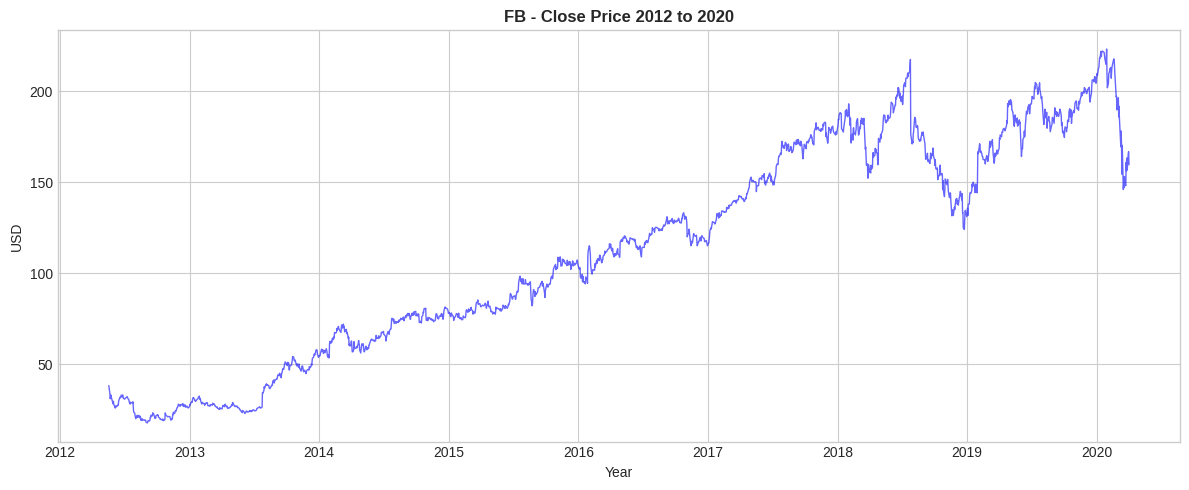

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(dfFB['Date'], dfFB['Close'], color='blue', alpha = 0.6, linewidth=1)

plt.title('FB - Close Price 2012 to 2020', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('USD')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

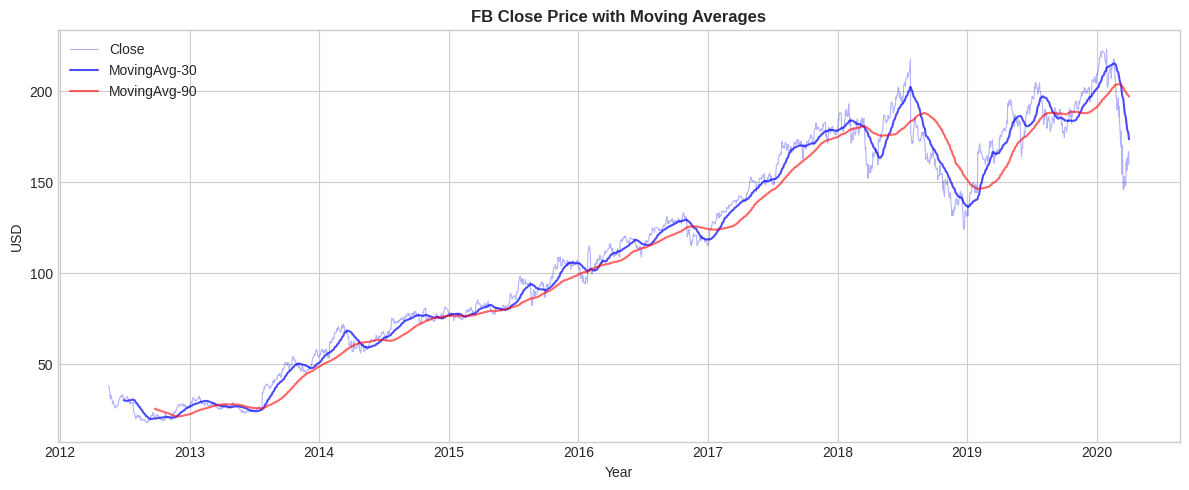

In [36]:
close = dfFB.set_index('Date')['Close']

plt.figure(figsize=(12, 5))

plt.plot(close.index, close,
         color='blue', linewidth=0.8, alpha=0.3, label='Close')
plt.plot(close.index, close.rolling(30).mean(),
         color='blue', linewidth=1.5, alpha = 0.7, label='MovingAvg-30')
plt.plot(close.index, close.rolling(90).mean(),
         color='red', linewidth=1.5, alpha = 0.6,  label='MovingAvg-90')

plt.title('FB Close Price with Moving Averages', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('USD')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

#### FB Dataset EDA Summary

time span of dataset: 2012-05-18 to 2020-04-01 ~ a little less than 8 years

from the EDA above, we can note down that in the FB dataset:

1. No missing values or duplicates

All 7 columns have the correct datatypes
- Date --> datettime
- Open, Close, High, Low --> indicate prices float64
- volume --> int


2. Close == Adj Close

FB has never performed a stock split or paid dividends during this dataset period. seen in the overlapping of Close and ADJ Close graph above. in the FB dataset Close and ADJ close are interchangable, but since we're expected to use Close, then just use Close

3. The overall trend of Close Prices against the years is positive, with a dip starting at mid 2018s to the 2019s until it steadily rises again. which is why in the moving average graph, we can see that MovingAvg-30 crossed below MovingAvg-90 in late 2018, telling us the bearish period of a stock market, before crossing back above in 2019

4. Non-stationary time series
- the price level and variance both change over time. This is expected for equity data and is the reason we normalise before feeding data into the LSTM.


### IBM Dataset

In [37]:
dfIBM.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
14658,2020-03-26,106.910004,113.150002,105.570000,112.889999,112.889999,7153500
14659,2020-03-27,108.580002,111.500000,107.650002,108.029999,108.029999,6423000
14660,2020-03-30,108.089996,113.459999,107.809998,112.930000,112.930000,5564500
14661,2020-03-31,112.000000,113.809998,110.169998,110.930000,110.930000,6343300
14662,2020-04-01,106.360001,109.919998,104.519997,105.139999,105.139999,6111900


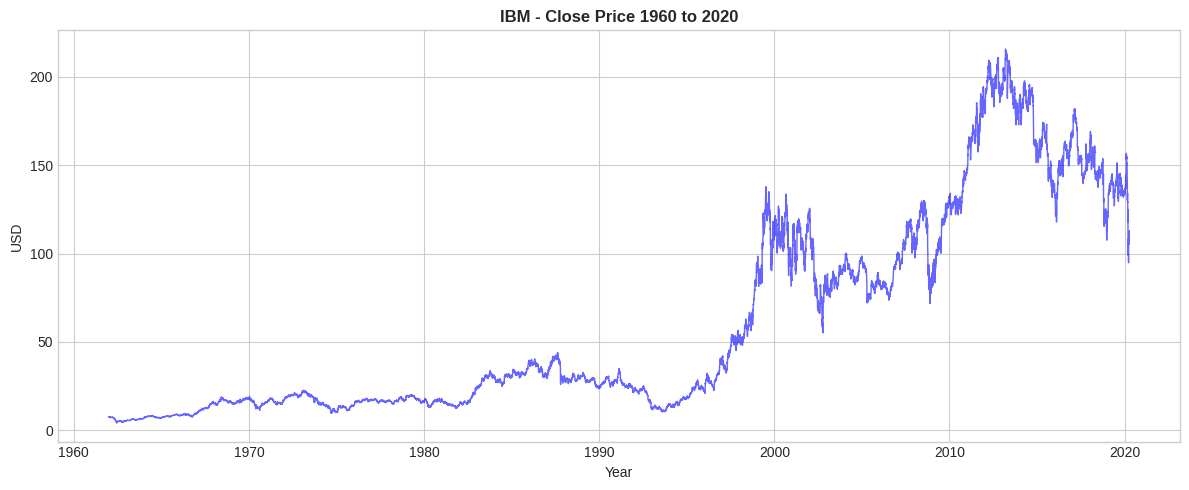

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(dfIBM['Date'], dfIBM['Close'], color='blue', alpha = 0.6, linewidth=1)

plt.title('IBM - Close Price 1960 to 2020', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('USD')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

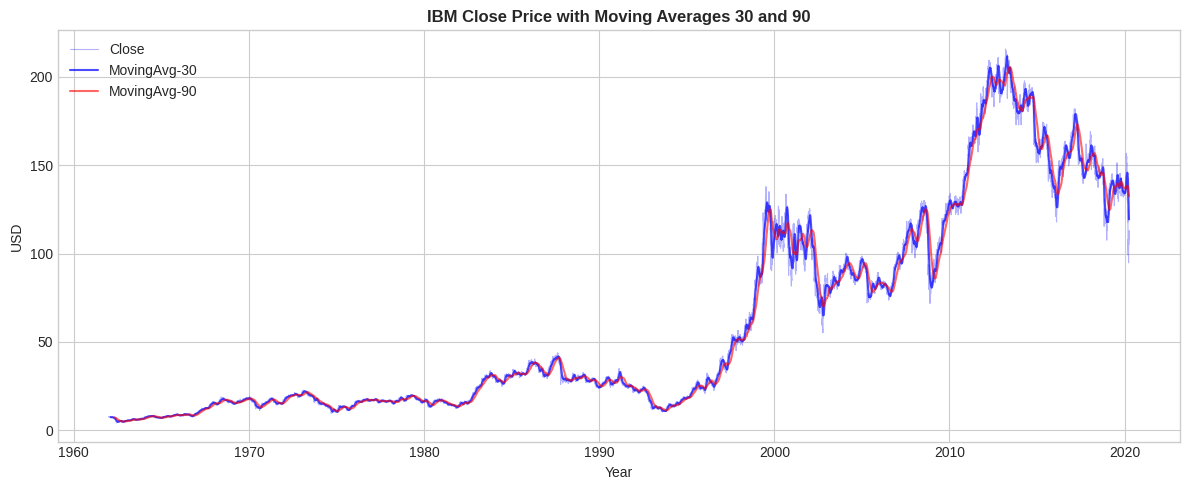

In [39]:
close = dfIBM.set_index('Date')['Close']

plt.figure(figsize=(12, 5))

plt.plot(close.index, close, color='blue', linewidth=0.8, alpha=0.3, label='Close')
plt.plot(close.index, close.rolling(30).mean(), color='blue', linewidth=1.5, alpha = 0.7, label='MovingAvg-30')
plt.plot(close.index, close.rolling(90).mean(), color='red', linewidth=1.5, alpha = 0.6,  label='MovingAvg-90')

plt.title('IBM Close Price with Moving Averages 30 and 90', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('USD')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [40]:
#i js wanted to see the trend of the data during the same time period as the FB dataset

ibmnotused = dfIBM[dfIBM['Date'] <  '2012-01-01']
ibmused = dfIBM[dfIBM['Date'] >= '2012-01-01']

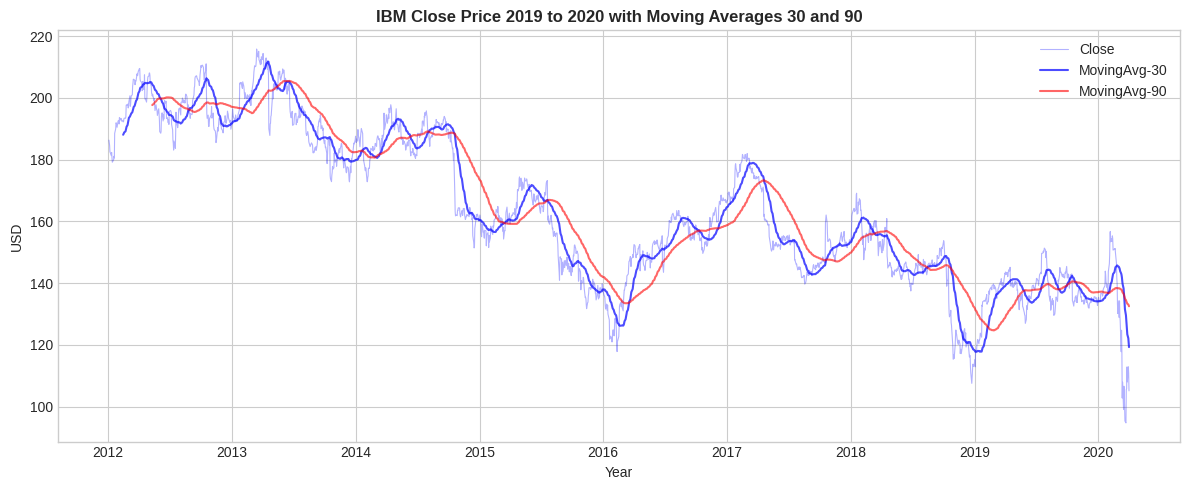

In [41]:
close = ibmused.set_index('Date')['Close']

plt.figure(figsize=(12, 5))

plt.plot(close.index, close, color='blue', linewidth=0.8, alpha=0.3, label='Close')
plt.plot(close.index, close.rolling(30).mean(), color='blue', linewidth=1.5, alpha = 0.7, label='MovingAvg-30')
plt.plot(close.index, close.rolling(90).mean(), color='red', linewidth=1.5, alpha = 0.6,  label='MovingAvg-90')

plt.title('IBM Close Price 2019 to 2020 with Moving Averages 30 and 90', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('USD')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

#### IBM Dataset EDA Summary

1. time span of the dataset: 1962-01-02 to 2020-04-01, roughly 58 years

!! Important
this means that the model has 58/8 = 7.25 times as many data on IBM to train on compared to FB

2. Close and Adj Close Graph DIVERGES.

IBM has paid dividends consistently since the 1960s and has undergone multiple stock splits.


3. No weekend entries
- An earlier column inspection of consecutive dates in 1962 appeared to suggest missng Saturday/Sunday data

- but verifying using dayofweek >= 5 confirms the opposite.

- there are zero weekend rows across all 58 years. The apparent consecutive sequence was because of manually counting row indexes rather than calendar days

4.

## Missing Date Gaps -- Linear Interpolation

- Both datasets have missing business days

we're linear interpolating between the known neighbours

since our window is going to be a moving, overlapping window, for an LSTM in a non stationary time series dataset,

then linear interpolation is needed to fill in the missing gaps

### FB Dataset

In [42]:
calendardays = pd.bdate_range(dfFB['Date'].min(), dfFB['Date'].max())

missing = calendardays.difference(dfFB['Date'])

print(f"Total business days in calendar: {len(calendardays)}")
print(f"Total rows in FB data: {len(dfFB)}")
print(f"Missing business days: {len(missing)}")
print()

missing_df = pd.DataFrame({'Date': missing})
missing_df['DayOfWeek'] = missing_df['Date'].dt.day_name()
print(missing_df.head(20).to_string(index=False))

Total business days in calendar: 2054
Total rows in FB data: 1980
Missing business days: 74

      Date DayOfWeek
2012-05-28    Monday
2012-07-04 Wednesday
2012-09-03    Monday
2012-10-29    Monday
2012-10-30   Tuesday
2012-11-22  Thursday
2012-12-25   Tuesday
2013-01-01   Tuesday
2013-01-21    Monday
2013-02-18    Monday
2013-03-29    Friday
2013-05-27    Monday
2013-07-04  Thursday
2013-09-02    Monday
2013-11-28  Thursday
2013-12-25 Wednesday
2014-01-01 Wednesday
2014-01-20    Monday
2014-02-17    Monday
2014-04-18    Friday


In [43]:
def check_missing_gaps(df):
    df = df.sort_values("Date")

    full = pd.DataFrame({
        "Date": pd.bdate_range(df["Date"].min(), df["Date"].max())
    })

    merged = full.merge(df[["Date"]], on="Date", how="left", indicator=True)

    merged["missing"] = merged["_merge"] == "left_only"

    groups = (merged["missing"] != merged["missing"].shift()).cumsum()

    gaps = (
        merged[merged["missing"]]
        .groupby(groups)
        .agg(
            Start=("Date","min"),
            End=("Date","max"),
            Length=("Date","count")
        )
        .reset_index(drop=True)
    )

    return gaps.sort_values("Length", ascending=False)

In [44]:
dfFB_close = dfFB[['Date', 'Close']].copy()
print("FB kolom yang digunakan:")
print(dfFB_close.head(3).to_string())
print(f"Shape: {dfFB.shape}")

FB kolom yang digunakan:
        Date      Close
0 2012-05-18  38.230000
1 2012-05-21  34.029999
2 2012-05-22  31.000000
Shape: (1980, 7)


In [45]:
fb_gaps = check_missing_gaps(dfFB_close)

print(fb_gaps.head(10))

       Start        End  Length
3 2012-10-29 2012-10-30       2
0 2012-05-28 2012-05-28       1
1 2012-07-04 2012-07-04       1
2 2012-09-03 2012-09-03       1
4 2012-11-22 2012-11-22       1
5 2012-12-25 2012-12-25       1
6 2013-01-01 2013-01-01       1
7 2013-01-21 2013-01-21       1
8 2013-02-18 2013-02-18       1
9 2013-03-29 2013-03-29       1


In [46]:
print(fb_gaps)

        Start        End  Length
3  2012-10-29 2012-10-30       2
0  2012-05-28 2012-05-28       1
1  2012-07-04 2012-07-04       1
2  2012-09-03 2012-09-03       1
4  2012-11-22 2012-11-22       1
..        ...        ...     ...
68 2019-11-28 2019-11-28       1
69 2019-12-25 2019-12-25       1
70 2020-01-01 2020-01-01       1
71 2020-01-20 2020-01-20       1
72 2020-02-17 2020-02-17       1

[73 rows x 3 columns]


In [47]:
dfFB_close.head()

,Date,Close
0,2012-05-18,38.230000
1,2012-05-21,34.029999
2,2012-05-22,31.000000
3,2012-05-23,32.000000
4,2012-05-24,33.029999


since the biggest gap is 2 days, it is still reasonable to use linear interpolation to fill in between these gaps with neighbouring values

#### Interpolation FB

In [48]:
dfFB_close = (dfFB_close.set_index("Date").asfreq("B"))

dfFB_close["Close"] = dfFB_close["Close"].interpolate("linear")

dfFB_close = dfFB_close.reset_index()

In [49]:
fb_gaps = check_missing_gaps(dfFB_close)

print(fb_gaps.head(10))

Empty DataFrame
Columns: [Start, End, Length]
Index: []


In [50]:
dfFB_close.head(10)

,Date,Close
0,2012-05-18,38.230000
1,2012-05-21,34.029999
2,2012-05-22,31.000000
3,2012-05-23,32.000000
4,2012-05-24,33.029999
5,2012-05-25,31.910000
6,2012-05-28,30.375000
7,2012-05-29,28.840000
8,2012-05-30,28.190001
9,2012-05-31,29.600000


### IBM Dataset

In [51]:
full_bdays = pd.bdate_range(dfIBM['Date'].min(), dfIBM['Date'].max())

missing = full_bdays.difference(dfIBM['Date'])

print(f"Total business days in calendar: {len(full_bdays)}")
print(f"Total rows in IBM data: {len(dfIBM)}")
print(f"Missing business days: {len(missing)}")
print()

missing_df = pd.DataFrame({'Date': missing})
missing_df['DayOfWeek'] = missing_df['Date'].dt.day_name()
print(missing_df.head(20).to_string(index=False))

Total business days in calendar: 15197
Total rows in IBM data: 14663
Missing business days: 534

      Date DayOfWeek
1962-02-22  Thursday
1962-04-20    Friday
1962-05-30 Wednesday
1962-07-04 Wednesday
1962-09-03    Monday
1962-11-06   Tuesday
1962-11-22  Thursday
1962-12-25   Tuesday
1963-01-01   Tuesday
1963-02-22    Friday
1963-04-12    Friday
1963-05-30  Thursday
1963-07-04  Thursday
1963-09-02    Monday
1963-11-05   Tuesday
1963-11-25    Monday
1963-11-28  Thursday
1963-12-25 Wednesday
1964-01-01 Wednesday
1964-02-21    Friday


In [52]:
missing_df.describe(include = "all")

,Date,DayOfWeek
count,534,534
unique,NaN,5
top,NaN,Monday
freq,NaN,239
mean,1990-06-18 19:27:38.426966272,NaN
min,1962-02-22 00:00:00,NaN
25%,1974-01-13 00:00:00,NaN
50%,1990-06-15 12:00:00,NaN
75%,2005-11-04 00:00:00,NaN
max,2020-02-17 00:00:00,NaN


In [53]:
dfIBM_close = dfIBM[['Date', 'Close']].copy()
print("IBM kolom yang digunakan:")
print(dfIBM_close.head(3).to_string())
print(f"Shape: {dfIBM_close.shape}")

IBM kolom yang digunakan:
        Date     Close
0 1962-01-02  7.626667
1 1962-01-03  7.693333
2 1962-01-04  7.616667
Shape: (14663, 2)


In [54]:
ibm_gaps = check_missing_gaps(dfIBM_close)

print(ibm_gaps)

         Start        End  Length
359 2001-09-11 2001-09-14       4
458 2012-10-29 2012-10-30       2
62  1968-07-04 1968-07-05       2
407 2007-01-01 2007-01-02       2
347 2000-05-29 2000-05-29       1
..         ...        ...     ...
178 1979-09-03 1979-09-03       1
179 1979-11-22 1979-11-22       1
180 1979-12-25 1979-12-25       1
181 1980-01-01 1980-01-01       1
173 1979-01-01 1979-01-01       1

[528 rows x 3 columns]


In [55]:
dfIBM_close.shape

(14663, 2)

the ibm dataset has a gap for 4 days between 2001-09-11 and 2001-09-14, these dates are known to be the September attack on the Twin Towers of the United states,

when i google searched abt this respective to IBM stocks

No IBM stock prices exist for September 11 through September 14, 2001, because the New York Stock Exchange (NYSE) and all major U.S. financial markets were closed. due to the attack

#### Interpolation IBM

In [56]:
dfIBM_close = (dfIBM_close.set_index("Date").asfreq("B"))

dfIBM_close["Close"] = dfIBM_close["Close"].interpolate("linear")

dfIBM_close = dfIBM_close.reset_index()

In [ ]:
ibm_gaps = check_missing_gaps(dfIBM_close)

print(ibm_gaps.head(10))

Empty DataFrame
Columns: [Start, End, Length]
Index: []


In [58]:
dfIBM_close.head(10)

,Date,Close
0,1962-01-02,7.626667
1,1962-01-03,7.693333
2,1962-01-04,7.616667
3,1962-01-05,7.466667
4,1962-01-08,7.326667
5,1962-01-09,7.413333
6,1962-01-10,7.426667
7,1962-01-11,7.506667
8,1962-01-12,7.520000
9,1962-01-15,7.553333


### INTERPOLATION SUMMARY

Why Linear Interpolation?
When the NYSE (New York Stock Exchange) closes for a public holiday, no price discovery takes place.

so there are no 'true' price for that day.

these gaps needs to be filled because our sliding window (size=5) assumes a dense, consecutive sequence of trading days.

A missing day would cause a window to accidentally span across two separate weeks, breaking the Mon- Fri weekly structure.

1. Gaps are short
- FB max = 2 days, IBM max = 4 days. For short gaps, the assumption of constant daily price drift between two known neighbours can be reasonable when NYSE was not open

2. Neutral assumption
- It does not introduce any directional bias. It simply smooths between the last known close and the next known open following a linear trend between these neighbours

3. Does not forward-fill
- Forward-fill copies the previous close into the missing day, creating fake flat periods that teaches the model of some small, suspicious zero-change patterns

4. Does not drop rows
- Dropping would create abrupt multi-day jumps in the sequence and alter the weekly window structure


from the dataset FB and IBM: we only use columns Date and Close

so dfFB --> dfFB_Close
dfIBM --> dfIBM_Close

before doing linear interpolation, the missing gaps in Date is something to consider, the amount and the biggest gap of missing dates.


1. FB DATASET
- number of missing business days: 74
- biggest gap in the missing days: 2

this is small enough in ratio to the whole FB dataset, making it okay to linearly interpolate


2. IBM DATASET
- number of missing business days: 534
- biggest gap in the missing days: 4

the biggest gap of missing days in the IBM dataset is because of the 9/11 closure back in 2001, in which he New York Stock Exchange (NYSE) did not open.





## Splitting LAST ONE YEAR

Selanjutnya, pisahkan dataset terlebih dahulu
menjadi data training dan data test, dengan data test mencakup periode satu tahun terakhir.


do not shuffle data, its time series it should be chronological

### FB

In [59]:
fb_last_date = dfFB_close["Date"].max()

fb_test_start = fb_last_date - pd.DateOffset(years=1)

fb_train = dfFB_close[dfFB_close["Date"] < fb_test_start].reset_index(drop=True)
fb_test  = dfFB_close[dfFB_close["Date"] >= fb_test_start].reset_index(drop=True)

print("FB")
print("Train:", fb_train.shape)
print("Test :", fb_test.shape)

print(fb_train["Date"].min(), "->", fb_train["Date"].max())
print(fb_test["Date"].min(), "->", fb_test["Date"].max())

FB
Train: (1791, 2)
Test : (263, 2)
2012-05-18 00:00:00 -> 2019-03-29 00:00:00
2019-04-01 00:00:00 -> 2020-04-01 00:00:00


In [60]:
fb_train.head()

,Date,Close
0,2012-05-18,38.230000
1,2012-05-21,34.029999
2,2012-05-22,31.000000
3,2012-05-23,32.000000
4,2012-05-24,33.029999


In [61]:
fb_test.head()

,Date,Close
0,2019-04-01,168.699997
1,2019-04-02,174.199997
2,2019-04-03,173.539993
3,2019-04-04,176.020004
4,2019-04-05,175.720001


### IBM

In [62]:
ibm_last_date = dfIBM_close["Date"].max()

ibm_test_start = ibm_last_date - pd.DateOffset(years=1)

ibm_train = dfIBM_close[dfIBM_close["Date"] < ibm_test_start].reset_index(drop=True)
ibm_test  = dfIBM_close[dfIBM_close["Date"] >= ibm_test_start].reset_index(drop=True)

print("IBM")
print("Train:", ibm_train.shape)
print("Test :", ibm_test.shape)

print(ibm_train["Date"].min(), "->", ibm_train["Date"].max())
print(ibm_test["Date"].min(), "->", ibm_test["Date"].max())

IBM
Train: (14934, 2)
Test : (263, 2)
1962-01-02 00:00:00 -> 2019-03-29 00:00:00
2019-04-01 00:00:00 -> 2020-04-01 00:00:00


In [63]:
ibm_train.head()

,Date,Close
0,1962-01-02,7.626667
1,1962-01-03,7.693333
2,1962-01-04,7.616667
3,1962-01-05,7.466667
4,1962-01-08,7.326667


In [64]:
ibm_test.head()

,Date,Close
0,2019-04-01,143.300003
1,2019-04-02,143.000000
2,2019-04-03,143.630005
3,2019-04-04,142.779999
4,2019-04-05,143.279999


## Scaling

we use MIN-MAX scaler because

LSTM uses the activation function sigmoid and tanh di in the gates.


both of these functions are more sensitive? responsive, returns the bigger gradient when the input is in 0-1 or 1 - -1 range.


stock prices like $150 atau $200 will result in a vwry small gradient and a very sloow training. either leading to a vanishing gradient or a slow convergance.



Scaler is only fitted to the training data, test data is only transformed, not fitted over.

if the test set is also fit to the scaler, then the model will receive an input that "knows" the max and min valyes of the test set, LSTM might accidentally get some sort of information abt the test set, which leads to data leakage


MIN MAX

Brings all prices into 0 - 1 without altering the shape of the distribution or the relative ordering of values.


X scaled = (x - xmin) / (xmax - xmin)

### FB

In [65]:
fb_scaler = MinMaxScaler()

fb_train_scaled = fb_scaler.fit_transform(fb_train[["Close"]])
fb_test_scaled  = fb_scaler.transform(fb_test[["Close"]])

### IBM

In [66]:
ibm_scaler = MinMaxScaler()

ibm_train_scaled = ibm_scaler.fit_transform(ibm_train[["Close"]])
ibm_test_scaled  = ibm_scaler.transform(ibm_test[["Close"]])

## Making Window

A sliding window with stride=1 was used instead of non-overlapping fixed blocks.

With window size = 5 and horizon = 1:

IF WE USE:
1. Non-overlapping (stride=5):

[D1–D5]→D6, [D6–D10]→D11, ... → from ~1,791 FB training days, only ~357 (X, y) pairs.


2. Overlapping (stride=1):

[D1–D5]→D6, [D2–D6]→D7, ... → from the same data, ~1,786 pairs  roughly 5× more training samples.


I chose this approach because


1. Data efficiency:

- thw FB datasets are relatively small. Overlapping windows extract the most possible supervised learning from the available historical data.

2. Real-world alignment:
- In practice, it is more common to predict tomorrow's price using the last 5 days every single day, not in discrete weekly blocks. The overlapping window mirrors this.


3. No leakage:

- Each (X, y) pair -->  X contains 5 days before y.
- The chronological train/test split ensures no test-period windows appear in training.

In [67]:
def create_dataset(data, window=5, horizon=1):

    X = []
    y = []

    for i in range(len(data) - window - horizon + 1):
        X.append(data[i:i+window])
        y.append(data[i+window+horizon-1])

    return np.array(X), np.array(y)

### FB

In [68]:
fb_X_train, fb_y_train = create_dataset(fb_train_scaled)
fb_X_test,  fb_y_test  = create_dataset(fb_test_scaled)

### IBM

In [69]:
ibm_X_train, ibm_y_train = create_dataset(ibm_train_scaled)
ibm_X_test,  ibm_y_test  = create_dataset(ibm_test_scaled)

## Splitting 90/10

Splitting Data

90% train
10% val


no shuffling needed because this is a time series data in which testing is the "future" data and training is the "past" data.

### FB

In [70]:
fb_X_train, fb_X_val, fb_y_train, fb_y_val = train_test_split(
    fb_X_train,
    fb_y_train,
    test_size=0.10,
    shuffle=False
)

### IBM

In [71]:
ibm_X_train, ibm_X_val, ibm_y_train, ibm_y_val = train_test_split(
    ibm_X_train,
    ibm_y_train,
    test_size=0.10,
    shuffle=False
)

# Baseline Model

 Buatlah arsitektur baseline dengan LSTM (units=50) dan layer akhir berupa
node Perceptron dengan units=1. Activation function untuk LSTM menggunakan ReLU

input
- batch size
- timetsamp = 5
- features = 1

LSTM
- 50 units
- activation layer = relu

into

dense layer
- 1 unit
+ percrptron node

output
- batch size 1 = prediction close prize thats normalized


LSTM (50 units, ReLU): The LSTM processes the sequence of 5 normalised closing prices and compresses them into a 50-dimensional hidden state vector. Each of the 50 units learns a different temporal pattern

Dense(1) — the Perceptron node: one linear neuron that takes the 50-dimensional LSTM output and produces one scalar: the predicted next-day price in normalized scale. No activation is in here because this is a regression output. so we need real values

Optimizer = Adam
- default lr=0.001
- Adam adapts the learning rate per parameter, making it robust to the noisy gradients

Loss = MSE
MSE penalises large prediction errors quadratically.

MSE squares the error terms, meaning the penalty increases ^2 as predictions strray further from true values.

In finance, severe mispredictions like a market crash is crucial

In [72]:
def build_baseline():

    model = Sequential([
        LSTM(
            units=50,
            activation='relu',
            input_shape=(5,1)
        ),
        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

## FB

In [73]:
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

fb_baseline = build_baseline()

history_fb = fb_baseline.fit(
    fb_X_train,
    fb_y_train,
    validation_data=(fb_X_val, fb_y_val),
    epochs=100,
    batch_size=32,
    callbacks=[earlystop],
    verbose=1
)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0604 - mae: 0.1757 - val_loss: 0.0011 - val_mae: 0.0248
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0021 - mae: 0.0348 - val_loss: 0.0019 - val_mae: 0.0289
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.1106e-04 - mae: 0.0130 - val_loss: 0.0013 - val_mae: 0.0224
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7581e-04 - mae: 0.0093 - val_loss: 0.0012 - val_mae: 0.0214
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6308e-04 - mae: 0.0088 - val_loss: 0.0011 - val_mae: 0.0210
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5969e-04 - mae: 0.0087 - val_loss: 0.0011 - val_mae: 0.0208
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5871e-04 - mae: 0.0087 - val_loss: 0.0011 - val_mae: 0.0207
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.5806e-04 - mae: 0.0086 - val_loss: 0.0011 - val_mae: 0.0206
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 

Epoch 3: train_loss = 2.2e-4, val_loss = 1.1e-3
Epoch 100: train_loss = 1.2e-4, val_loss = 6.6e-4

train loss and val loss are both still decreasing at epoch 100. the model hasn't converged yet.

EarlyStopping with patience=10 didn't run because val_loss kept slowly improving every epoch.

the models will likely still improve with more epochs, however epoch is still defined as 100 since the modified model will have more.


The gap between train loss (1.2e-4) and val loss (6.6e-4) is about 5x.

the model generalises less well on validation than on training. this doesnt automatically indicate overfitting in stock IPO data


it's more likely just that the validation window representing a slightly different price regime than training

Training MAE at epoch 100 is 0.0075 in a normalised scale.it is a reasonable number of mae for a baseline model, however this is still not the optimal output of this model

## IBM

In [74]:
ibm_baseline = build_baseline()

history_ibm = ibm_baseline.fit(
    ibm_X_train,
    ibm_y_train,
    validation_data=(ibm_X_val, ibm_y_val),
    epochs=100,
    batch_size=32,
    callbacks=[earlystop],
    verbose=1
)

Epoch 1/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0053 - mae: 0.0236 - val_loss: 2.1108e-04 - val_mae: 0.0113
Epoch 2/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.8576e-05 - mae: 0.0041 - val_loss: 2.0496e-04 - val_mae: 0.0111
Epoch 3/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5.8425e-05 - mae: 0.0041 - val_loss: 2.0786e-04 - val_mae: 0.0112
Epoch 4/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.8585e-05 - mae: 0.0042 - val_loss: 2.2312e-04 - val_mae: 0.0118
Epoch 5/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.8104e-05 - mae: 0.0043 - val_loss: 2.2613e-04 - val_mae: 0.0120
Epoch 6/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5.7332e-05 - mae: 0.0043 - val_loss: 2.2838e-04 - val_mae: 0.0122
Epoch 7/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5.6700e-05 - mae: 0.0043 - val_loss: 2.2315e-04 - val_mae: 0.0120
Epoch 8/100
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.6180e-05 - mae: 0.0043 - val_loss: 2.2362e-04 - val_

val_loss is fluctuating while train loss kept decreasing (3.5e-5 at epoch 29 and still going down at 34), but val_loss is going upward.

The model started memorising training patterns that don't generalise to the validation data.


Why does IBM overfit faster than FB?

- IBM training data is 14.400 rows. its much larger than FB

- More data means the model reaches a well-fitted state sooner, and with only 50 LSTM units there isn't much spare capacity to keep improving without starting to overfit

- IBM also has 58 years of price history from very different market period.

- the validation period from the later IBM data is structurally different from much of the training data, so generalisation is harder --> from graph of overall trend

# Modified Model

modifikasi arsitektur
pada nomor 1c untuk mendapatkan unjuk kerja yang optimal (kalian dapat menambahkan atau
mengurangi arsitektur tersebut, atau mengganti hyperparameter, atau menggunakan tuning
pada hyperparameter). Jelaskan alasan kalian untuk menggunakan pendekatan yang kalian pilih.

input:
- batch size 5, 1

LSTM --> output batch size 64
- 64
- activatin=on fuction = relu

Dense layer --> output batch size 8
- 8
- activation function = relu

Dense layer
- 1
- no activation function

output --> batchsize 1



Changes compared to Baseline Model:

1. LSTM units:

50 --> 64

now that we have a bigger hidden state layer, the model should be able to catch and learn more temporal patterns from the time series dataset

- this can lead to some small improvements for the model loss, but it can also lead to some overfitting for smaller datasets like FB


2. Addition:

Dense(8, relu) between LSTM and output

--> now theres a non linear transformation layer in hopes for the model to capture more complex non linear data which can map out specific details to patterns

- can potentially improve generalisation for stock price dynamics that are not linear


3. Optimizer:

Adam (lr=0.0005)

decrease the learning rate by half

- can lead to slower converging of model but can reduce the chance of oscillating around the loss minimum on noisy data


In [75]:
def build_improved():
    model = Sequential([
        LSTM(
            64,
            activation='relu',
            input_shape=(5,1)
        ),
        Dense(8, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='mse',
        metrics=['mae']
    )

    return model

## FB

In [76]:
fb_improved = build_improved()

history_fb2 = fb_improved.fit(
    fb_X_train,
    fb_y_train,
    validation_data=(fb_X_val, fb_y_val),
    epochs=120,
    batch_size=32,
    callbacks=[earlystop],
    verbose=1
)

Epoch 1/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1865 - mae: 0.3497 - val_loss: 0.3393 - val_mae: 0.5780
Epoch 2/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0937 - mae: 0.2384 - val_loss: 0.0933 - val_mae: 0.3012
Epoch 3/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0081 - mae: 0.0513 - val_loss: 0.0013 - val_mae: 0.0229
Epoch 4/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2772e-04 - mae: 0.0113 - val_loss: 0.0012 - val_mae: 0.0217
Epoch 5/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8982e-04 - mae: 0.0099 - val_loss: 0.0012 - val_mae: 0.0217
Epoch 6/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8179e-04 - mae: 0.0095 - val_loss: 0.0012 - val_mae: 0.0218
Epoch 7/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.7798e-04 - mae: 0.0093 - val_loss: 0.0012 - val_mae: 0.0218
Epoch 8/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7565e-04 - mae: 0.0092 - val_loss: 0.0012 - val_mae: 0.0218
Epoch 9/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s

The model starts from a much higher initial loss at 0.1328 at epoch 1 vs 0.0052 for baseline. This is because the added Dense(8, relu) layer initialises with random weights. The combined random LSTM + Dense(8) + Dense(1) stack produces very poor predictions initially.

The model then drops fast: by epoch 3 val_loss = 2.3e-3, comparable to where baseline was around epoch 3 val_loss = 1.1e-3. So the improved model is slightly slower to converge early on.

By epoch 10 train_loss = 2.2e-4, val_loss = 1.5e-3. Comparing it to baseline at epoch 10, train loss was roughly similar but val_loss was already lower for baseline.

the modified model is actually performing worse on validation than the baseline during early training.

the lower learning rate ,0.0005 vs Adam default 0.001, combined with the extra Dense(8) layer means the model takes more steps to reach the same loss as baseline.

if training is continued above epoch 100, it may eventually converge to a better solution, but with only 100 epochs and no extended patience, the modified model may not have had enough time to exploit its extra capacity. and it has not converged yet



## IBM

In [77]:
ibm_improved = build_improved()

history_ibm2 = ibm_improved.fit(
    ibm_X_train,
    ibm_y_train,
    validation_data=(ibm_X_val, ibm_y_val),
    epochs=120,
    batch_size=32,
    callbacks=[earlystop],
    verbose=1
)

Epoch 1/120
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0105 - mae: 0.0354 - val_loss: 1.8076e-04 - val_mae: 0.0102
Epoch 2/120
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.5528e-05 - mae: 0.0042 - val_loss: 1.9726e-04 - val_mae: 0.0109
Epoch 3/120
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.5482e-05 - mae: 0.0042 - val_loss: 2.1903e-04 - val_mae: 0.0118
Epoch 4/120
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5.5146e-05 - mae: 0.0042 - val_loss: 2.2117e-04 - val_mae: 0.0120
Epoch 5/120
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 5.4698e-05 - mae: 0.0043 - val_loss: 2.1746e-04 - val_mae: 0.0119
Epoch 6/120
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.4252e-05 - mae: 0.0043 - val_loss: 2.1762e-04 - val_mae: 0.0119
Epoch 7/120
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5.3734e-05 - mae: 0.0043 - val_loss: 2.1004e-04 - val_mae: 0.0116
Epoch 8/120
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 5.2961e-05 - mae: 0.0043 - val_loss: 1.9989e-04 - val_

Epoch 1: val_loss = 2.28e-4
Epoch 2: val_loss = 2.35e-4
Epoch 3: val_loss = 2.45e-4
Epoch 4: val_loss = 2.46e-4


Val_loss is increasing from epoch 1. The model is overfitting very quickly.

EarlyStopping, patience=10 would run around epoch 11-12, restoring weights from epoch 1, which means the best the improved model achieves is its very first epoch's weights.

The added Dense(8, relu) layer gives the model extra capacity.

Combined with IBM's large and long spanning time, training dataset, the model finds it easier to memorise recent training patterns than to generalise

for IBM baseline, the best was epoch 29, giving the model 29 epochs of useful learning. IBM improved gets approximately 1 useful epoch.




In [78]:
print(fb_X_train.shape)
print(fb_X_val.shape)
print(ibm_X_train.shape)
print(ibm_X_val.shape)

(1607, 5, 1)
(179, 5, 1)
(13436, 5, 1)
(1493, 5, 1)


# Prediction and Metrics for Both Models

### Model Prediction func

In [79]:
def predict_model(model, X_test, scaler):
    """
    Returns:
        y_pred : predicted Close prices (original scale)
    """

    y_pred = model.predict(X_test, verbose=0)
    y_pred = scaler.inverse_transform(y_pred)

    return y_pred

### metrics prediction func

In [80]:
def evaluate_model(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return rmse, mae, mape

In [81]:
def plot_prediction(y_true, y_pred, title):

    plt.figure(figsize=(12,5))

    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

## FB

### Baseline

In [82]:
fb_pred_baseline = predict_model(
    fb_baseline,
    fb_X_test,
    fb_scaler
)

In [83]:
fb_true = fb_scaler.inverse_transform(fb_y_test)

In [84]:
print("FB BASELINE")
fb_base_metrics = evaluate_model(fb_true, fb_pred_baseline)

FB BASELINE
RMSE : 4.2679
MAE  : 3.2005
MAPE : 1.71%


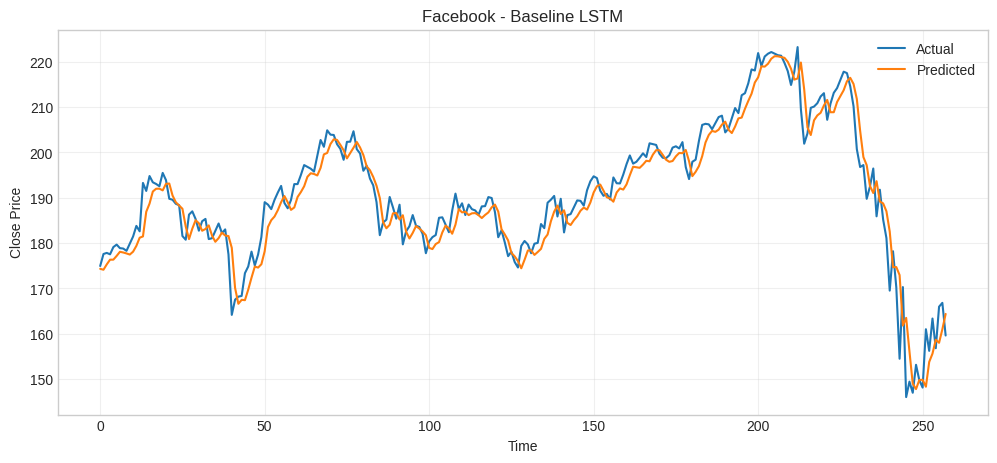

In [85]:
plot_prediction(
    fb_true,
    fb_pred_baseline,
    "Facebook - Baseline LSTM")


### Improved

In [86]:
fb_pred_improved = predict_model(
    fb_improved,
    fb_X_test,
    fb_scaler
)

In [87]:
fb_true = fb_scaler.inverse_transform(fb_y_test)

In [88]:
print("FB IMPROVED")
fb_imp_metrics = evaluate_model(fb_true, fb_pred_improved)

FB IMPROVED
RMSE : 146.9315
MAE  : 146.2710
MAPE : 76.45%


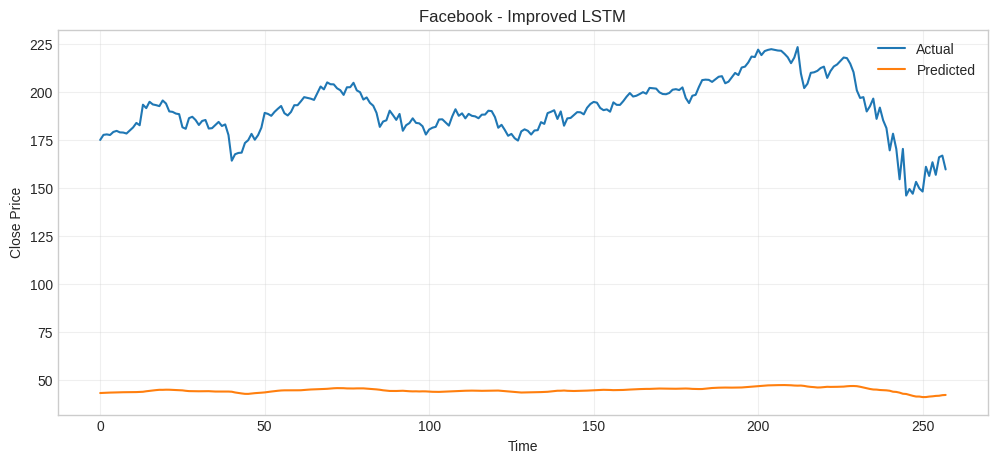

In [89]:
plot_prediction(
    fb_true,
    fb_pred_improved,
    "Facebook - Improved LSTM")

### FB Baseline VS Improved

IMPROVED

FB IMPROVED
RMSE : 88.7447
MAE  : 88.2009
MAPE : 46.04%

the predicted orange line sits at a roughly flat ~90 - 110 band while actual prices range 150 - 225. The predicted line still wiggles a little, but it's been compressed into a narrow band that never tracks the real scale of the data.

this can be because of inverse_transform being applied to predictions that were never properly trained on the right scale, or if the model never converge

looking back at the training results for the last epoch for the improved FB model

Epoch 10: val_loss = 0.0015

this is still 2x higher than baseline's epoch 100 value of 0.00066. this ccan be caused by the early stopping

the epoch was cut short while val_loss was still an fluctuating a lot compared to the baseline's converged loss, the model hasnt learned the price scale relationship yet and instead had only learned the general average.





## IBM

### Baseline

In [90]:
ibm_pred_baseline = predict_model(
    ibm_baseline,
    ibm_X_test,
    ibm_scaler
)

In [91]:
ibm_true = ibm_scaler.inverse_transform(ibm_y_test)

In [92]:
print("IBM BASELINE")
ibm_base_metrics = evaluate_model(ibm_true, ibm_pred_baseline)

IBM BASELINE
RMSE : 3.2639
MAE  : 2.5276
MAPE : 1.90%


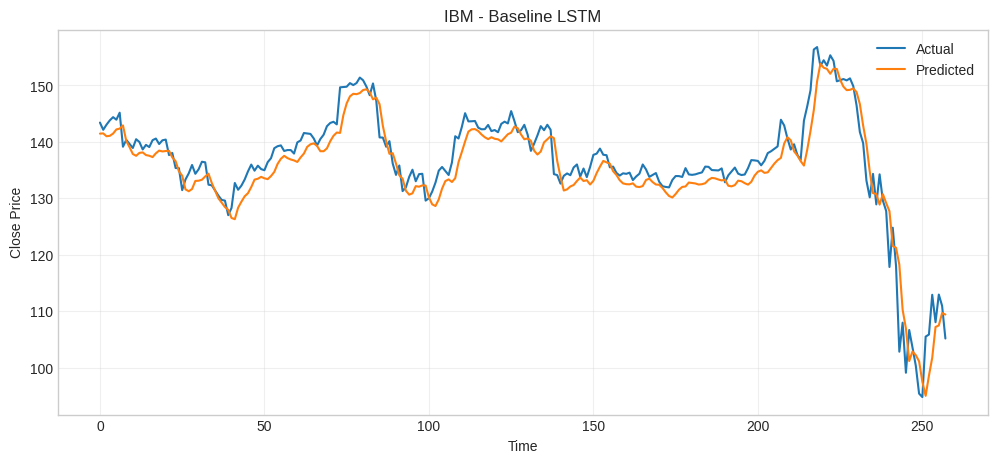

In [93]:
plot_prediction(
    ibm_true,
    ibm_pred_baseline,
    "IBM - Baseline LSTM"
)

### Improved

In [94]:
ibm_pred_improved = predict_model(
    ibm_improved,
    ibm_X_test,
    ibm_scaler
)

In [95]:
ibm_true = ibm_scaler.inverse_transform(ibm_y_test)

In [96]:
print("IBM IMPROVED")
ibm_imp_metrics = evaluate_model(ibm_true, ibm_pred_improved)

IBM IMPROVED
RMSE : 3.7329
MAE  : 2.6358
MAPE : 2.00%


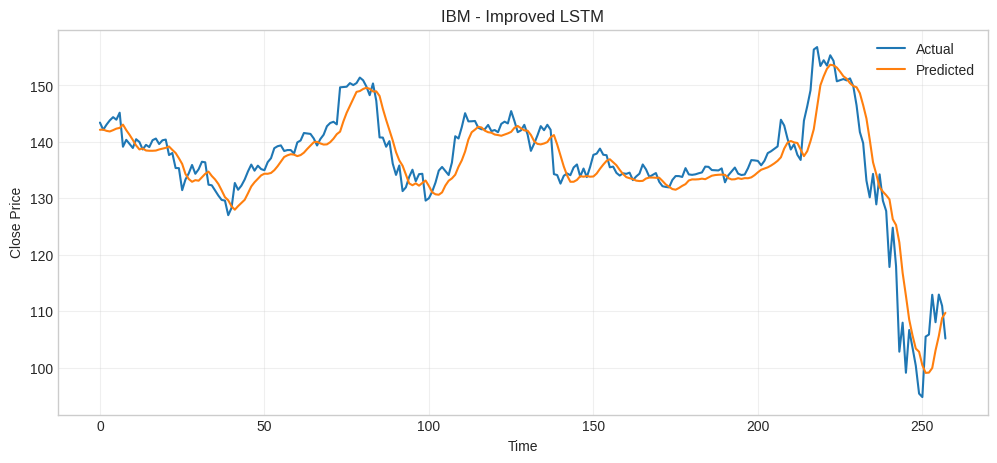

In [97]:
plot_prediction(
    ibm_true,
    ibm_pred_improved,
    "IBM - Improved LSTM")

### IBM Baseline VS Improved

IBM BASELINE
- RMSE : 3.2639
- MAE  : 2.5276
- MAPE : 1.90%

IBM IMPROVED
- RMSE : 3.7329
- MAE  : 2.6358
- MAPE : 2.00%


the modified model is working slightly worse than the baseline model, but the graph shows that the model is still tracking the actual trend reasonably well, just with looser, noisier predictions

especially visible in the choppy middle section around index 100 - 140, and a bit of lag entering the crash around index 220 - 250/

training log diagnosis from before shows that IBM Improved's val_loss started rising from epoch 1


meaning that EarlyStopping likely restored very early weights. the model barely got to learn before patience ran out.

it is still a functional but overfits relative to baseline

## Performance MODEL Analysis RMSE, MAE MAPE



FB has roughly 8x less training data than IBM.

The added Dense(8) layer increases model parameters.

With less data from the FB dataset and the same epoch budget and lower LR, FB's improved model ran out of training time before reaching convergence.

FB baseline ran the full 100 epochs and, despite not being fully converged, got close enough to make results that were reasonably good. Mape = 1.72%

IBM, despite overfitting, had enough data and epochs early on to learn something useful before EarlyStopping cut it off. thats why the previous graph was still following the trend, however not as close as the baseline model.




FB BASELINE
- RMSE : 4.2679
- MAE  : 3.2005
- MAPE : 1.71%


FB IMPROVED
- RMSE : 146.9315
- MAE  : 146.2710
- MAPE : 76.45%



IBM BASELINE
- RMSE : 3.2639
- MAE  : 2.5276
- MAPE : 1.90%

IBM IMPROVED
- RMSE : 3.7329
- MAE  : 2.6358
- MAPE : 2.00%

RMSE/Root Mean Squared Error

The average prediction error in USD. large errors are punished heavily because errors get squared before averaging.

If the model miss by 20, then it will contribute 400 to the average. So RMSE > MAE, the bigger the gap between them, the more "spike" errors it has.



MAE/Mean Absolute Error

The real average daily miss in USD. If MAE = 3.20, then on average the model prediction was 3.20 off from the real price each day. No squaring, so every day contributes equally regardless of how bad the miss was.


MAPE/Mean Absolute Percentage Error

The same idea as MAE but expressed as a percentage of the actual price. A 3 error on a 150 stock and a 3 error on a 30 stock can be seen in ratio through percentage.

##### FB BASELINE

On average the model missed by 3.20 per day on a stock trading of 150 - 225, which is 1.71% of the actual price. it is a good prediction, resulting in errors lower than 2% of the actual price

The RMSE being $1.07 higher than MAE

shows that there are occasional larger errors most likely during the COVID crash days but there is no big spikes or misses.

overall the FB baseline model fits closely to the actual data

##### FB Improved

the model degraded further on this modification.

MAPE 76% means predictions are off by three-quarters of the actual price on average.

RMSE and MAE are almost identical $146.93 vs $146.27, which means that the errors are usually just as bad every single day. The model is predicting a somehwa constant value across all 258 test days. the random weight initialisation may land in a particularly bad local minimum that the low learning rate (0.0005) and limited epochs couldn't learn from

##### IBM BASELINE

MAE 2.53

--> take the difference between what the model predicted and what the price actually was then average all of those = 2.53

if IBM actually closed at 135.00, the model predicted somewhere around 132.47 or 137.53


RMSE 3.26 vs MAE 2.53

0.73 gap. That gap tells you there are some days where the model missed by significantly more than 2.53, pulling the RMSE up


MAPE 1.90%

the average error relative to the actual price is 1.90%. At 130 actual price, a 1.90% error means the prediction was off by about 2.47. it is a relatively close prediction


##### IBM Modified

MAE 2.64

if IBM actually closed at 135.00, the model predicted somewhere around 132.36 or 137.64. That's 0.11 worse than baseline's 2.53 daily miss.


RMSE 3.73

The gap between RMSE and MAE here is 1.09, compared to baseline's gap of 0.73. That larger gap means the improved model has more days where it misses by a lot. the spike errors are sharper or more frequent than baseline. the data around 2019 and 2020 where it may show the covid crash might impact more to this model because Dense(8) layer overfit some training patterns that made it less stable when prices moved quickly

MAPE 2.00%

At 130 actual price, 2.00% means the model was off by about $2.60 on average.

compared to baseline's 2.47 at the same price. The difference between 1.90% and 2.00% is 0.10 percentage points. which means the modified model does perform slightly worse than the baseline model, however it is still close to it.


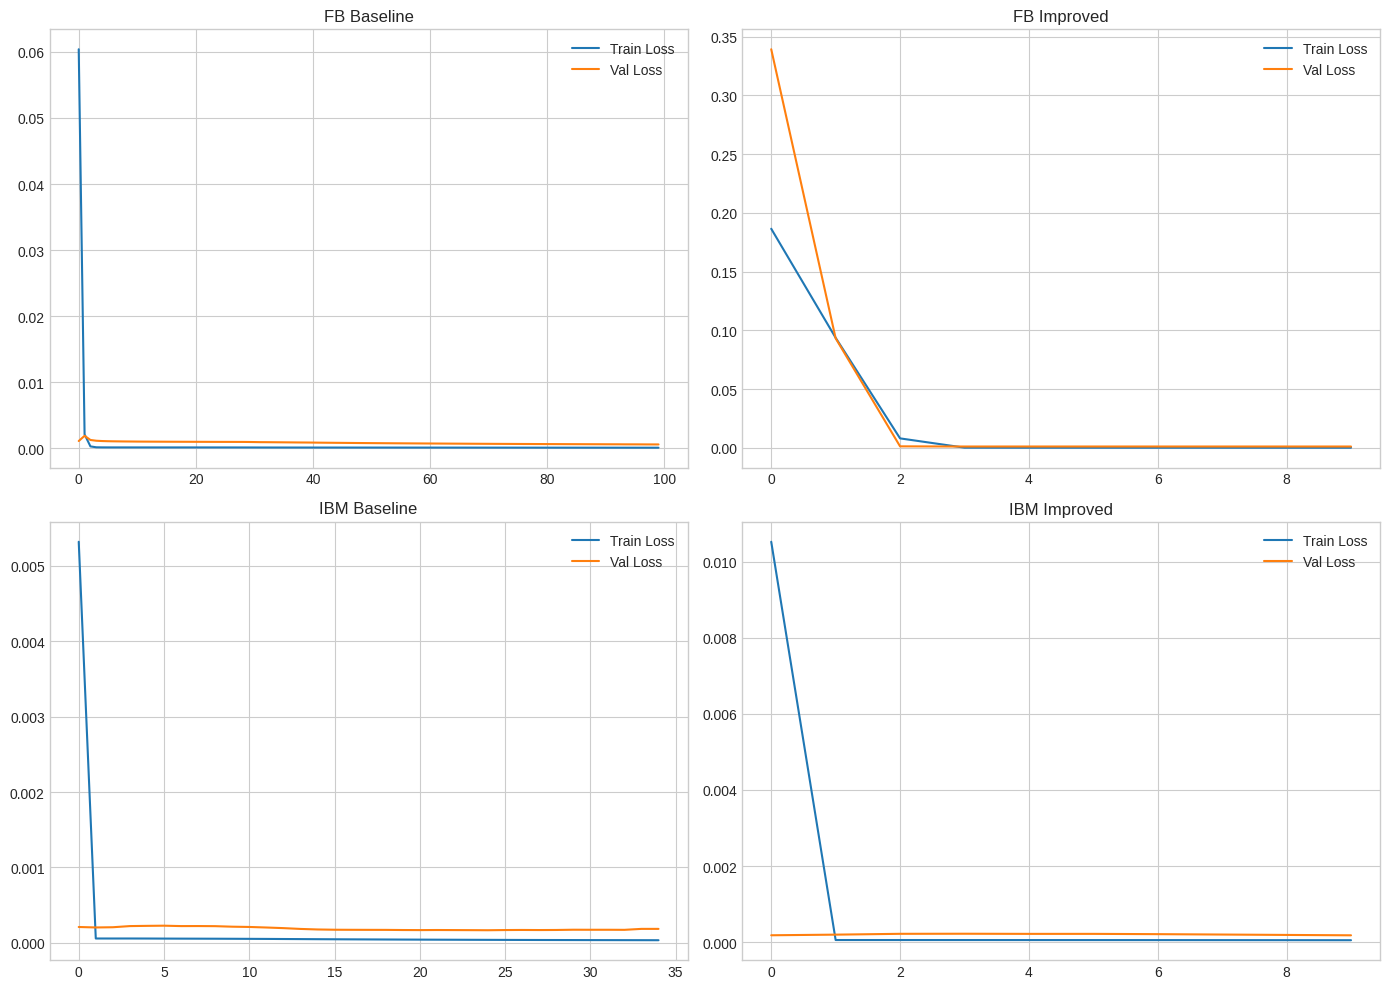

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(history_fb.history['loss'], label='Train Loss')
axes[0,0].plot(history_fb.history['val_loss'], label='Val Loss')
axes[0,0].set_title('FB Baseline')
axes[0,0].legend()

axes[0,1].plot(history_fb2.history['loss'], label='Train Loss')
axes[0,1].plot(history_fb2.history['val_loss'], label='Val Loss')
axes[0,1].set_title('FB Improved')
axes[0,1].legend()

axes[1,0].plot(history_ibm.history['loss'], label='Train Loss')
axes[1,0].plot(history_ibm.history['val_loss'], label='Val Loss')
axes[1,0].set_title('IBM Baseline')
axes[1,0].legend()

axes[1,1].plot(history_ibm2.history['loss'], label='Train Loss')
axes[1,1].plot(history_ibm2.history['val_loss'], label='Val Loss')
axes[1,1].set_title('IBM Improved')
axes[1,1].legend()

plt.tight_layout()
plt.show()

FB has roughly 8x less training data than IBM.

The added Dense(8) layer increases model parameters.

With less data from the FB dataset and the same epoch budget and lower LR, FB's improved model ran out of training time before reaching convergence.

FB baseline ran the full 100 epochs and, despite not being fully converged, got close enough to make results that were reasonably good. Mape = 1.72%

IBM, despite overfitting, had enough data and epochs early on to learn something useful before EarlyStopping cut it off. thats why the previous graph was still following the trend, however not as close as the baseline model.


train loss decreases on all models using all datasets, the model still does work in order to try and capture insights and patterns of the data

however the train loss looks like a flat line in this graph because of the scale of the y-axis. since train loss is dropping from a much higher starting value, so val loss's actual movement gets visually flattened.

except for FB Improved

Val_loss at epoch 1 is computed using the same untrained random weights, just evaluated on the validation set instead of the training set. Since the model hasn't learned anything yet, train and val loss should be similar at epoch 1 and they are: loss: 0.1328 vs val_loss: 0.1173.



the baseline model has around 10400 parameters

the modified model has around 17,400: LSTM 16,896, Dense(8) 520, Dense(1) 9 parameters


FB training row: 1791

IBM training row: 14934

FB baseline --> converges properly --> taking the full 100 epochs

FB improved --> using the same smaller dataset for a model of nearly twice the parameters caused the model to be undtrained and it settled for a local minimum of the general average trend


IBM baseline --> the dataset is large enough for a model of that parameter size. however the model slightly overfits at epoch 29 and that weight was the best weight taken by EarlyStopping


IBM improved --> the model is now bigger and it overfits the IBM dataset faster than before, earlystopping decided that the best weight done was at epoch 1